<img src="Banner%20Hands-on.jpg" alt="Banner Hands-on" style="width:100%;">


# <font color="EB9A54"><center> **Hands-on Sesión 6: Estimación activa de la profundidad 📷 💡** </center></font>

## **Contenido**

[**1. ¿Qué es depth activo?**](#tema1)

[**2. Datos LiDAR y formato de nube de puntos**](#tema2)

[**3. Carga y visualización de datos**](#tema3)

[**4. Range image: nube 3D → imagen de profundidad**](#tema4)

[**5. Clustering simple de objetos**](#tema5)

[**6. Referencias**](#referencias)

<a name="tema1"></a>
## <font color='#4C5FDA'>**1. ¿Qué es la estimacion activa de la profundidad activo?** </font>

En **depth activo**, el sistema no espera pasivamente a que la escena esté iluminada. En cambio, **emite energía** —por ejemplo, luz láser o patrones infrarrojos— y mide cómo regresa esa señal.

Ejemplos comunes:

- **LiDAR:** emite pulsos láser y estima distancia usando tiempo de vuelo.
- **Structured light:** proyecta patrones conocidos y triangula profundidad.
- **Active stereo:** usa cámaras estéreo y un patrón activo para mejorar correspondencias.
- **ToF camera:** mide el tiempo o fase de retorno de la luz.

En este notebook nos enfocaremos en **LiDAR**, porque permite mostrar de forma muy visual la geometría 3D de una escena.

## **Idea física básica**

Un LiDAR mide distancia porque conoce la velocidad de propagación de la luz. Si el sensor emite un pulso y recibe el eco después de un tiempo $\Delta t$, una aproximación de la distancia radial es:

$$
r = \frac{c \Delta t}{2}
$$

El factor $2$ aparece porque la luz viaja **del sensor al objeto** y luego **del objeto al sensor**.

En muchos datasets LiDAR no se guarda directamente el histograma temporal, sino puntos ya reconstruidos:

$$
p_i = (x_i, y_i, z_i, I_i)
$$

donde:

- $x_i, y_i, z_i$: coordenadas 3D del punto.
- $I_i$: intensidad del retorno.

<a name="tema2"></a>
## <font color='#4C5FDA'>**2. Datos LiDAR y formato de nube de puntos** </font>

Usaremos el formato típico de KITTI/MMDetection3D:

```text
[x, y, z, intensity]
```

Cada archivo `.bin` contiene muchos números `float32`. Al leerlos, se reorganizan como una matriz de tamaño:

```text
N puntos × 4 columnas
```

Este notebook intentará descargar un frame LiDAR público de ejemplo. Si la descarga falla, se genera una escena LiDAR sintética para que la clase pueda continuar.

In [26]:
#@title Instalación de librerías

# En Colab normalmente solo se necesita instalar plotly/sklearn si no están disponibles.
# La bandera -q reduce el texto en pantalla.
!pip install -q plotly scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [27]:
#@title Cargamos librerías

import os
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.cluster import DBSCAN

np.set_printoptions(precision=3, suppress=True)

In [28]:
#@title Funciones necesarias

def download_file(url, output_path):
    """Descarga un archivo pequeño desde una URL."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, output_path)
    return output_path


def load_kitti_bin(path):
    """Lee una nube LiDAR en formato KITTI: x, y, z, intensity."""
    points = np.fromfile(path, dtype=np.float32)
    if points.size % 4 != 0:
        raise ValueError("El archivo no parece tener formato KITTI: cantidad de floats no múltiplo de 4.")
    return points.reshape(-1, 4)


def generate_synthetic_lidar(seed=7, n_ground=9000, n_objects=2600):
    """
    Genera una nube de puntos sintética tipo LiDAR.
    No reemplaza datos reales, pero sirve como respaldo didáctico.
    """
    rng = np.random.default_rng(seed)

    # Suelo: puntos en una región frontal
    x_ground = rng.uniform(0, 55, n_ground)
    y_ground = rng.uniform(-25, 25, n_ground)
    z_ground = rng.normal(0.0, 0.03, n_ground)
    i_ground = rng.uniform(0.1, 0.5, n_ground)

    ground = np.column_stack([x_ground, y_ground, z_ground, i_ground])

    # Objetos: tres "bloques" de puntos
    centers = np.array([
        [14, -5, 1.0],
        [26,  7, 1.2],
        [38, -2, 1.5],
    ])
    sizes = np.array([
        [3.0, 1.8, 2.0],
        [4.0, 2.2, 2.4],
        [2.5, 2.5, 3.0],
    ])

    obj_points = []
    per_obj = n_objects // len(centers)

    for center, size in zip(centers, sizes):
        local = rng.uniform(-0.5, 0.5, size=(per_obj, 3)) * size
        pts = center + local

        # Dejamos la base de los objetos sobre el suelo
        pts[:, 2] = np.maximum(pts[:, 2], 0.05)

        intensity = rng.uniform(0.45, 1.0, per_obj)
        obj_points.append(np.column_stack([pts, intensity]))

    return np.vstack([ground] + obj_points).astype(np.float32)


def basic_stats(points):
    """Imprime estadísticas básicas de la nube."""
    xyz = points[:, :3]
    ranges = np.linalg.norm(xyz, axis=1)

    print("Número de puntos:", len(points))
    print("Columnas:", points.shape[1], "→ x, y, z, intensity")
    print("Rango mínimo / medio / máximo [m]:", ranges.min(), ranges.mean(), ranges.max())
    print("x min/max:", xyz[:, 0].min(), xyz[:, 0].max())
    print("y min/max:", xyz[:, 1].min(), xyz[:, 1].max())
    print("z min/max:", xyz[:, 2].min(), xyz[:, 2].max())


def subsample(points, max_points=8000, seed=0):
    """Submuestrea puntos para visualización rápida."""
    if len(points) <= max_points:
        return points
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx]


def plot_point_cloud(points, color_by="range", max_points=8000, title="Nube de puntos LiDAR"):
    """
    Visualización 3D interactiva con Plotly.
    color_by puede ser: 'range', 'z' o 'intensity'.
    """
    pts = subsample(points, max_points=max_points)
    xyz = pts[:, :3]
    ranges = np.linalg.norm(xyz, axis=1)

    if color_by == "z":
        color = xyz[:, 2]
        label = "Altura z"
    elif color_by == "intensity":
        color = pts[:, 3]
        label = "Intensidad"
    else:
        color = ranges
        label = "Rango"

    fig = go.Figure(data=[
        go.Scatter3d(
            x=xyz[:, 0],
            y=xyz[:, 1],
            z=xyz[:, 2],
            mode="markers",
            marker=dict(
                size=2,
                color=color,
                colorscale="Viridis",
                opacity=0.8,
                colorbar=dict(title=label)
            )
        )
    ])

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x [m]",
            yaxis_title="y [m]",
            zaxis_title="z [m]",
            aspectmode="data"
        ),
        width=900,
        height=650
    )
    fig.show()



def compute_range_image(
    points,
    H=64,
    W=512,
    v_fov=(-25, 3),
    h_fov=(-70, 70),
    min_range=0.5,
    max_range=80.0
):
    """
    Convierte puntos 3D en una imagen de profundidad/rango.

    H: número de filas, similar a canales verticales del LiDAR.
    W: resolución angular horizontal.
    v_fov: campo de visión vertical aproximado en grados.
    h_fov: campo de visión horizontal en grados. Usar un FOV frontal evita
           que la imagen quede con muchas columnas vacías.
    min_range, max_range: rango válido de distancias en metros.

    Nota:
    Si varios puntos caen en el mismo píxel, se guarda el más cercano.
    """
    xyz = points[:, :3]
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    r = np.linalg.norm(xyz, axis=1)

    eps = 1e-9
    azimuth = np.arctan2(y, x)
    elevation = np.arcsin(z / np.maximum(r, eps))

    el_min, el_max = np.deg2rad(v_fov[0]), np.deg2rad(v_fov[1])
    az_min, az_max = np.deg2rad(h_fov[0]), np.deg2rad(h_fov[1])

    u = ((azimuth - az_min) / (az_max - az_min) * (W - 1)).astype(int)
    v = (1 - (elevation - el_min) / (el_max - el_min)) * (H - 1)
    v = v.astype(int)

    valid = (
        (r >= min_range) & (r <= max_range) &
        (azimuth >= az_min) & (azimuth <= az_max) &
        (elevation >= el_min) & (elevation <= el_max) &
        (u >= 0) & (u < W) &
        (v >= 0) & (v < H)
    )

    flat_idx = v[valid] * W + u[valid]
    range_flat = np.full(H * W, np.inf, dtype=np.float32)
    np.minimum.at(range_flat, flat_idx, r[valid].astype(np.float32))

    range_img = range_flat.reshape(H, W)
    range_img[~np.isfinite(range_img)] = np.nan
    return range_img


def crop_valid_region(img, pad_rows=2, pad_cols=8):
    """
    Recorta automáticamente la región que contiene mediciones válidas.
    Esto ayuda a evitar imágenes con mucho espacio vacío.
    """
    valid = np.isfinite(img)

    if not valid.any():
        return img

    rows = np.where(valid.any(axis=1))[0]
    cols = np.where(valid.any(axis=0))[0]

    r0 = max(0, rows.min() - pad_rows)
    r1 = min(img.shape[0], rows.max() + pad_rows + 1)
    c0 = max(0, cols.min() - pad_cols)
    c1 = min(img.shape[1], cols.max() + pad_cols + 1)

    return img[r0:r1, c0:c1]


def plot_range_image(
    range_img,
    title="Range image LiDAR",
    crop=True,
    inverse_depth=False,
    percentile_clip=(2, 98),
    figsize=(14, 4)
):
    """
    Visualización más bonita de una range image.

    crop=True recorta la región con datos.
    inverse_depth=True muestra cercanía 1/r, útil para que objetos cercanos resalten.
    percentile_clip evita que puntos extremadamente lejanos dominen la escala de color.
    """
    img = range_img.copy()

    if crop:
        img = crop_valid_region(img)

    valid = np.isfinite(img)
    if not valid.any():
        print("No hay mediciones válidas para graficar.")
        return

    if inverse_depth:
        img_to_show = np.full_like(img, np.nan, dtype=np.float32)
        img_to_show[valid] = 1.0 / img[valid]
        label = "Cercanía 1 / distancia [1/m]"
    else:
        img_to_show = img
        label = "Distancia radial [m]"

    vmin, vmax = np.nanpercentile(img_to_show, percentile_clip)
    img_masked = np.ma.masked_invalid(img_to_show)

    cmap = plt.cm.inferno.copy()
    cmap.set_bad(color="black")

    plt.figure(figsize=figsize)
    plt.imshow(
        img_masked,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Ángulo horizontal / azimut")
    plt.ylabel("Ángulo vertical / canal LiDAR")
    plt.tight_layout()
    plt.show()


def compute_bev(points, xlim=(0, 50), ylim=(-25, 25), resolution=0.25, mode="height"):
    """
    Crea una vista bird's-eye view.
    mode='height' guarda altura máxima por celda.
    mode='density' guarda cantidad de puntos por celda.
    """
    xyz = points[:, :3]
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]

    mask = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])
    x, y, z = x[mask], y[mask], z[mask]

    W = int((xlim[1] - xlim[0]) / resolution)
    H = int((ylim[1] - ylim[0]) / resolution)

    col = ((x - xlim[0]) / resolution).astype(int)
    row = ((y - ylim[0]) / resolution).astype(int)

    col = np.clip(col, 0, W - 1)
    row = np.clip(row, 0, H - 1)

    if mode == "density":
        bev = np.zeros((H, W), dtype=np.float32)
        np.add.at(bev, (row, col), 1)
        bev = np.log1p(bev)
    else:
        bev = np.full((H, W), np.nan, dtype=np.float32)
        flat = row * W + col
        bev_flat = np.full(H * W, -np.inf, dtype=np.float32)
        np.maximum.at(bev_flat, flat, z.astype(np.float32))
        bev = bev_flat.reshape(H, W)
        bev[~np.isfinite(bev)] = np.nan

    return bev


def plot_bev(bev, title="Vista BEV"):
    plt.figure(figsize=(10, 8))
    plt.imshow(bev, cmap="viridis", origin="lower", aspect="auto")
    plt.colorbar(label="Altura máxima o densidad")
    plt.title(title)
    plt.xlabel("x frontal")
    plt.ylabel("y lateral")
    plt.show()

<a name="tema3"></a>
## <font color='#4C5FDA'>**3. Carga y visualización de datos** </font>


La siguiente celda intenta descargar un frame LiDAR de ejemplo. Si no hay internet o el archivo no está disponible, se genera una nube sintética.

**Nota:** en una sesión real, también puedes pedir que los estudiantes suban un archivo `.bin` de KITTI/SemanticKITTI.

In [29]:
#@title Carga de datos LiDAR

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Frame LiDAR de ejemplo usado en demos antiguos de MMDetection3D.
# Si falla, el notebook sigue con nube sintética.
SAMPLE_URL = "https://raw.githubusercontent.com/open-mmlab/mmdetection3d/v0.13.0/demo/data/kitti/kitti_000008.bin"
SAMPLE_PATH = DATA_DIR / "kitti_000008.bin"

use_synthetic = False

try:
    if not SAMPLE_PATH.exists():
        print("Descargando frame LiDAR de ejemplo...")
        download_file(SAMPLE_URL, SAMPLE_PATH)

    points = load_kitti_bin(SAMPLE_PATH)
    print("Datos reales cargados desde:", SAMPLE_PATH)

except Exception as e:
    print("No se pudo descargar/cargar el frame real.")
    print("Motivo:", repr(e))
    print("Generando nube LiDAR sintética para continuar la sesión...")
    points = generate_synthetic_lidar()
    use_synthetic = True

basic_stats(points)

Datos reales cargados desde: data/kitti_000008.bin
Número de puntos: 17238
Columnas: 4 → x, y, z, intensity
Rango mínimo / medio / máximo [m]: 3.7393115 14.366324 79.52871
x min/max: 2.889 76.835
y min/max: -26.42 10.278
z min/max: -3.607 2.866


In [30]:
#@title Visualización 3D de la nube de puntos

plot_point_cloud(
    points,
    color_by="range",
    max_points=9000,
    title="Nube de puntos LiDAR: color por distancia"
)

<div style="background-color:#a82757; padding:14px; border-left:6px solid ##f2facf; border-radius:6px">

## **RETO 1 — Explorar distancia**

Cambia el valor de `max_range_reto` y observa qué partes de la escena desaparecen.

Preguntas guía:

1. ¿Qué puntos quedan si solo miramos hasta 15 m?
2. ¿Qué cambia si usamos 30 m o 60 m?
3. ¿Los objetos lejanos se ven más dispersos o más densos?

</div>

In [38]:
#@title RETO 1: filtrar puntos por distancia

xyz = points[:, :3]
ranges = np.linalg.norm(xyz, axis=1)

# TODO: cambia este valor y vuelve a ejecutar.
max_range_reto = 70 # metros

mask_close = ranges < max_range_reto
points_close = points[mask_close]

print(f"Puntos dentro de {max_range_reto} m:", len(points_close), "de", len(points))

plot_point_cloud(
    points_close,
    color_by="range",
    max_points=8000,
    title=f"Puntos LiDAR con distancia < {max_range_reto} m"
)

Puntos dentro de 70 m: 17102 de 17238


<a name="tema4"></a>
## <font color='#4C5FDA'>**4. Range image: nube 3D → imagen de profundidad**</font> 


Un LiDAR giratorio produce mediciones en ángulos horizontales y verticales. Por eso podemos proyectar la nube 3D a una imagen 2D:

- eje horizontal: ángulo de azimut.
- eje vertical: canal o elevación del láser.
- valor del píxel: distancia medida.

Esta representación se llama **range image** y es muy usada porque permite tratar una nube LiDAR como si fuera una imagen.

> **Nota visual:** si usamos los 360° completos del LiDAR, muchas columnas pueden quedar vacías.  
> Para que la figura sea más legible en clase, aquí visualizamos principalmente el **campo frontal** y recortamos automáticamente las zonas sin mediciones.


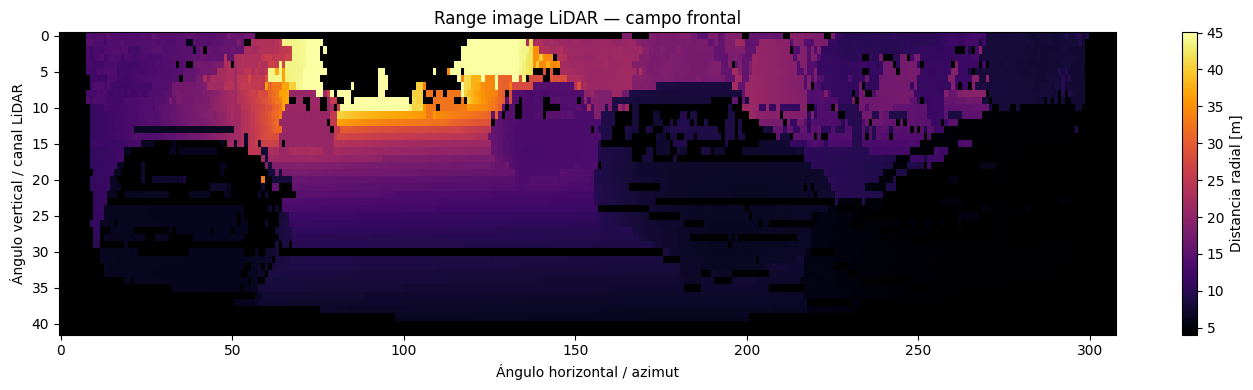

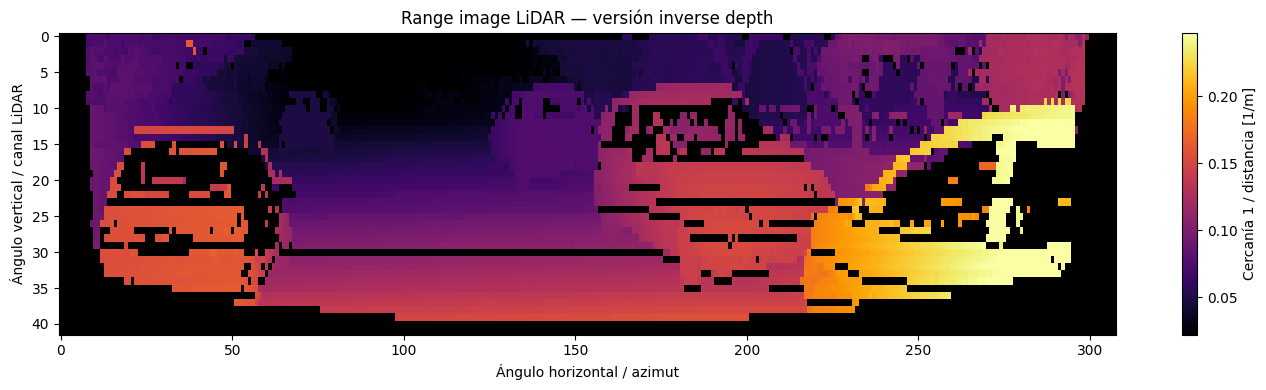

In [32]:
#@title Crear y visualizar range image

range_img = compute_range_image(
    points_close,
    H=64,
    W=512,
    v_fov=(-25, 3),
    h_fov=(-70, 70),
    min_range=0.5,
    max_range=80.0
)

plot_range_image(
    range_img,
    title="Range image LiDAR — campo frontal",
    crop=True,
    inverse_depth=False
)

plot_range_image(
    range_img,
    title="Range image LiDAR — versión inverse depth",
    crop=True,
    inverse_depth=True
)


<div style="background-color:#a82757; padding:14px; border-left:6px solid ##f2facf; border-radius:6px">

## **RETO 2 — Cambiar la resolución de la range image**

Modifica `H`, `W` y `v_fov`.

Sugerencias:

- Usa `H=32` y luego `H=128`.
- Usa `W=512` y luego `W=2048`.
- Cambia el campo vertical `v_fov=(-20, 10)`.

Pregunta: ¿qué pasa con los huecos de la imagen cuando aumenta la resolución?

</div>

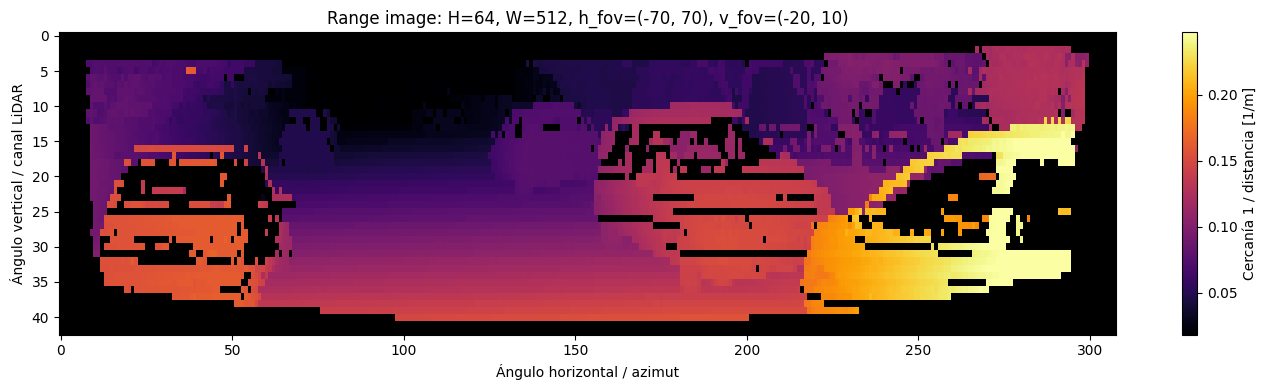

In [90]:
#@title RETO 2: jugar con H, W y campo de visión

# TODO: cambia estos parámetros.
H_reto = 64
W_reto = 512
v_fov_reto = (-20, 10)
h_fov_reto = (-70, 70)

range_img_reto = compute_range_image(
    points,
    H=H_reto,
    W=W_reto,
    v_fov=v_fov_reto,
    h_fov=h_fov_reto,
    min_range=0.5,
    max_range=80.0
    
)

plot_range_image(
    range_img_reto,
    title=f"Range image: H={H_reto}, W={W_reto}, h_fov={h_fov_reto}, v_fov={v_fov_reto}",
    crop=True,
    inverse_depth=True
)


## **Mini explicación: ¿por qué hay huecos?**

Una cámara RGB entrega una cuadrícula densa: casi todos los píxeles tienen color.  
Un LiDAR, en cambio, produce muestras discretas en rayos específicos. Por eso la range image puede tener muchos píxeles vacíos.


<div style="background-color:#a82757; padding:14px; border-left:6px solid ##f2facf; border-radius:6px">

## **RETO 3 — Ajustar la separación suelo/obstáculo**

Cambia `ground_margin`.

Sugerencias:

- Prueba `0.10`.
- Prueba `0.50`.
- Observa si estás eliminando demasiados objetos o dejando demasiado suelo.

Pregunta: ¿por qué una regla fija de altura puede fallar en una calle inclinada?

</div>

In [93]:
#@title RETO 3: cambiar margen de suelo

# TODO: cambia este margen.
ground_margin_reto = 0.5

z_base_reto = np.percentile(points[:, 2], 15)
ground_mask_reto = points[:, 2] < (z_base_reto + ground_margin_reto)
object_points_reto = points[~ground_mask_reto]

print("Margen:", ground_margin_reto)
print("Puntos posibles obstáculos:", len(object_points_reto))

plot_point_cloud(
    object_points_reto,
    color_by="z",
    max_points=8000,
    title=f"Posibles obstáculos con ground_margin={ground_margin_reto}"
)

Margen: 0.5
Puntos posibles obstáculos: 10986


<a name="tema5"></a>
## <font color='#4C5FDA'>**5. Clustering simple de objetos**</font>


Después de quitar suelo, podemos intentar agrupar puntos cercanos.  
Una técnica clásica para esto es **DBSCAN**, que agrupa puntos si están suficientemente cerca y marca como ruido los puntos aislados.

No vamos a hacer detección 3D profunda; solo una intuición básica:

```text
suelo removido → puntos restantes → clusters → posibles objetos
```

In [94]:
#@title Clustering DBSCAN de posibles obstáculos

# Limitamos la región para que DBSCAN sea rápido y más estable.
obj = object_points_reto.copy()
x, y, z = obj[:, 0], obj[:, 1], obj[:, 2]

roi_mask = (
    (x > 0) & (x < 45) &
    (y > -18) & (y < 18) &
    (z > z_base_reto + 0.10)
)

obj_roi = obj[roi_mask]

# Submuestreo para mantenerlo rápido.
obj_roi = subsample(obj_roi, max_points=6000, seed=10)

# Usamos solo coordenadas espaciales.
X_cluster = obj_roi[:, :3]

eps = 0.9
min_samples = 25

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_cluster)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Clusters encontrados:", n_clusters)
print("Puntos marcados como ruido:", n_noise)

# Visualización coloreada por cluster
fig = go.Figure(data=[
    go.Scatter3d(
        x=obj_roi[:, 0],
        y=obj_roi[:, 1],
        z=obj_roi[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=labels,
            colorscale="Turbo",
            opacity=0.85,
            colorbar=dict(title="Cluster")
        )
    )
])

fig.update_layout(
    title=f"DBSCAN sobre puntos no suelo: eps={eps}, min_samples={min_samples}",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="data"
    ),
    width=900,
    height=650
)
fig.show()

Clusters encontrados: 14
Puntos marcados como ruido: 324


<div style="background-color:#a82757; padding:14px; border-left:6px solid ##f2facf; border-radius:6px">

## **RETO 4 — Jugar con DBSCAN**

Modifica:

- `eps`: distancia máxima entre puntos vecinos.
- `min_samples`: cantidad mínima de vecinos para formar cluster.

Sugerencias:

- Si `eps` es muy pequeño, un objeto puede partirse en muchos clusters.
- Si `eps` es muy grande, varios objetos pueden unirse en un solo cluster.
- Si `min_samples` es alto, aparecen más puntos como ruido.

</div>

In [ ]:
#@title RETO 5: experimentar con DBSCAN

# TODO: cambia estos valores y observa los clusters.
eps_reto = 0.8
min_samples_reto = 20

db_reto = DBSCAN(eps=eps_reto, min_samples=min_samples_reto).fit(X_cluster)
labels_reto = db_reto.labels_

n_clusters_reto = len(set(labels_reto)) - (1 if -1 in labels_reto else 0)
print("Clusters encontrados:", n_clusters_reto)

fig = go.Figure(data=[
    go.Scatter3d(
        x=obj_roi[:, 0],
        y=obj_roi[:, 1],
        z=obj_roi[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=labels_reto,
            colorscale="Turbo",
            opacity=0.85,
            colorbar=dict(title="Cluster")
        )
    )
])

fig.update_layout(
    title=f"RETO DBSCAN: eps={eps_reto}, min_samples={min_samples_reto}",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="data"
    ),
    width=900,
    height=650
)
fig.show()

Clusters encontrados: 15


<a name="referencias"></a>
## <font color='#4C5FDA'>**6. Referencias**</font> <a name="tema1">

- KITTI Vision Benchmark: https://www.cvlibs.net/datasets/kitti/
- SemanticKITTI API: https://github.com/PRBonn/semantic-kitti-api
- Open3D: https://www.open3d.org/
- MMDetection3D demos: https://mmdetection3d.readthedocs.io/
- DBSCAN en scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html